In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load data
df = pd.read_csv("data/data.csv")

# Basic check
df.shape

C:\Users\tozeq\AppData\Local\Temp\ipykernel_8856\2063205132.py:2: DtypeWarning: Columns (0: box) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/data.csv")


(1095429, 36)

### First sanity checks

In [4]:
df.head()

,call_number,unit_id,incident_number,call_type,call_date,watch_date,received_dttm,entry_dttm,dispatch_dttm,response_dttm,...,number_of_alarms,unit_type,unit_sequence_in_call_dispatch,fire_prevention_district,supervisor_district,neighborhoods_analysis_boundaries,rowid,case_location,data_as_of,data_loaded_at
0,230010392,T03,23000066,Gas Leak (Natural and LP Gases),2023-01-01T00:00:00.000,2022-12-31T00:00:00.000,2023-01-01T01:56:38.000,2023-01-01T01:58:36.000,2023-01-01T01:59:03.000,2023-01-01T02:02:27.000,...,1,TRUCK,1.0,1.0,6.0,Tenderloin,230010392-T03,POINT (-122.41316 37.786728),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000
1,230010428,52,23000073,Medical Incident,2023-01-01T00:00:00.000,2022-12-31T00:00:00.000,2023-01-01T02:10:43.000,2023-01-01T02:12:06.000,2023-01-01T02:13:10.000,2023-01-01T02:13:50.000,...,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,230010428-52,POINT (-122.39453 37.724693),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000
2,230011485,B05,23000257,Alarms,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01T11:33:00.000,2023-01-01T11:34:23.000,2023-01-01T11:34:29.000,2023-01-01T11:35:00.000,...,1,CHIEF,3.0,5.0,1.0,Lone Mountain/USF,230011485-B05,POINT (-122.446846 37.777668),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000
3,230011085,86,23000201,Medical Incident,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01T08:28:08.000,2023-01-01T08:30:11.000,2023-01-01T08:32:00.000,2023-01-01T08:32:03.000,...,1,MEDIC,4.0,8.0,4.0,Sunset/Parkside,230011085-86,POINT (-122.5007 37.762524),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000
4,230012990,T03,23000486,Medical Incident,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01T20:30:52.000,2023-01-01T20:31:40.000,2023-01-01T20:32:44.000,NaN,...,1,TRUCK,3.0,1.0,3.0,Tenderloin,230012990-T03,POINT (-122.41335 37.787663),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095429 entries, 0 to 1095428
Data columns (total 36 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   call_number                        1095429 non-null  int64  
 1   unit_id                            1095429 non-null  str    
 2   incident_number                    1095429 non-null  int64  
 3   call_type                          1095429 non-null  str    
 4   call_date                          1095429 non-null  str    
 5   watch_date                         1095429 non-null  str    
 6   received_dttm                      1095429 non-null  str    
 7   entry_dttm                         1095429 non-null  str    
 8   dispatch_dttm                      1095429 non-null  str    
 9   response_dttm                      1066742 non-null  str    
 10  on_scene_dttm                      855028 non-null   str    
 11  transport_dttm                     

In [6]:
df.isna().sum()

call_number                               0
unit_id                                   0
incident_number                           0
call_type                                 0
call_date                                 0
watch_date                                0
received_dttm                             0
entry_dttm                                0
dispatch_dttm                             0
response_dttm                         28687
on_scene_dttm                        240401
transport_dttm                       834750
hospital_dttm                        839024
call_final_disposition                    0
available_dttm                          216
address                                 110
city                                   1323
zipcode_of_incident                     836
battalion                                 0
station_area                             52
box                                      50
original_priority                      6480
priority                        

# EDA for delay definition

### Convert timestamps + create response time

Right now all timestamps are strings, so we fix that first.

Convert to datetime

In [7]:
# Convert relevant columns to datetime
datetime_cols = [
    'received_dttm',
    'dispatch_dttm',
    'response_dttm',
    'on_scene_dttm'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

### Create response time (in seconds)

In [8]:
# Compute response time in seconds
df['response_time'] = (df['on_scene_dttm'] - df['received_dttm']).dt.total_seconds()

### Check invalid values

In [9]:
# Negative response times
(df['response_time'] < 0).sum()

np.int64(51)

In [10]:
# Missing response times
df['response_time'].isna().sum()

np.int64(240401)

### Clean response time (for analysis only)

Now we create a clean subset for delay definition.

In [11]:
# Keep only valid response times
df_clean = df[
    (df['response_time'].notna()) & 
    (df['response_time'] >= 0)
].copy()

df_clean.shape

(854977, 37)

In [12]:
# Sanity check

df_clean['response_time'].describe()

count    854977.000000
mean        692.541372
std        1807.284284
min           0.000000
25%         356.000000
50%         485.000000
75%         781.000000
max      623136.000000
Name: response_time, dtype: float64

### Distribution of response time

Understand the distribution

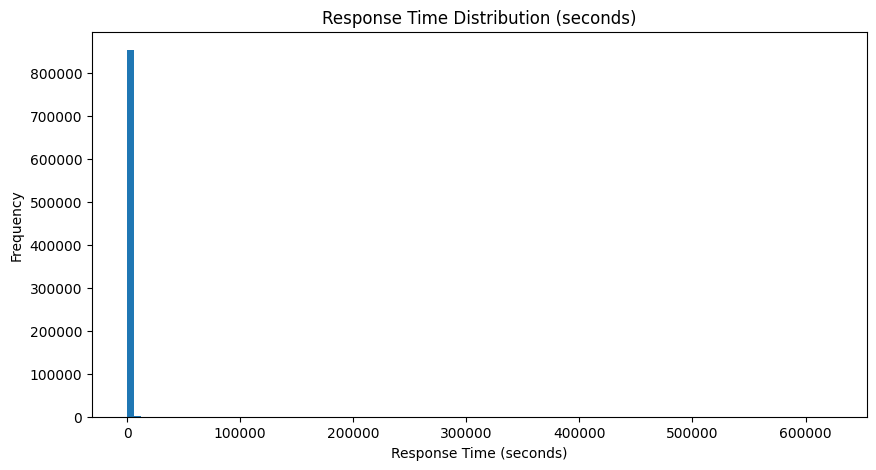

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df_clean['response_time'], bins=100)
plt.title("Response Time Distribution (seconds)")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.show()

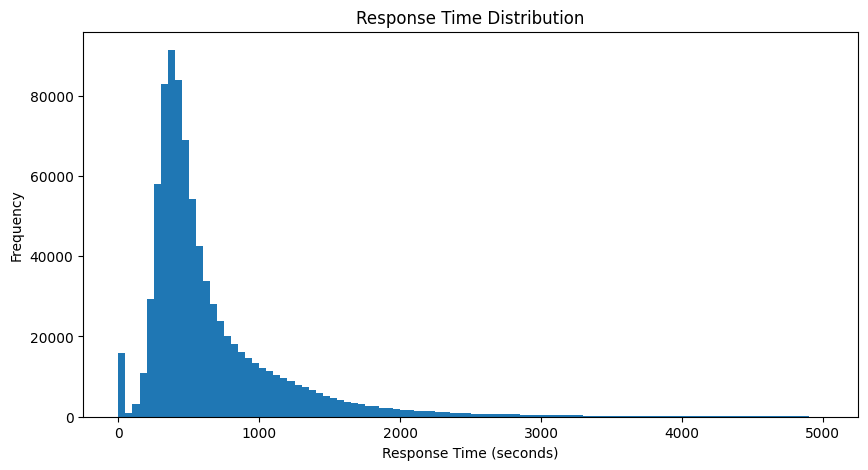

In [14]:

plt.figure(figsize=(10,5))

# Filter for visualization only (NOT for analysis)
df_plot = df_clean[df_clean['response_time'] <= 5000]

plt.hist(df_plot['response_time'], bins=100)

plt.title("Response Time Distribution")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### Key percentiles

In [15]:
df_clean['response_time'].quantile([0.5, 0.75, 0.8, 0.9, 0.95, 0.99])

0.50     485.0
0.75     781.0
0.80     905.0
0.90    1290.0
0.95    1700.2
0.99    3084.0
Name: response_time, dtype: float64

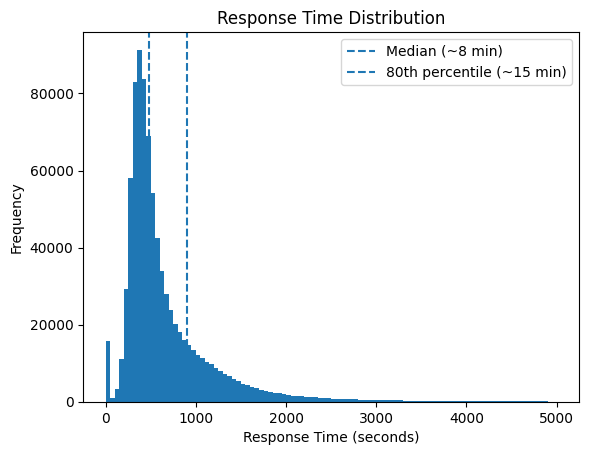

In [16]:

df_plot = df_clean[df_clean['response_time'] <= 5000]

plt.hist(df_plot['response_time'], bins=100)

# Add percentile lines
plt.axvline(485, linestyle='--', label='Median (~8 min)')
plt.axvline(905, linestyle='--', label='80th percentile (~15 min)')

plt.title("Response Time Distribution")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Breakdown by call type + priority

In [17]:
# Grouped percentiles
grouped = df_clean.groupby(['call_type', 'priority'])['response_time'].quantile(0.8)

grouped.sort_values().head(20)

call_type                           priority
Other                               I             0.0
Outside Fire                        A             0.0
Other                               E             0.0
Administrative                      2            27.0
Vehicle Fire                        2           287.0
Alarms                              2           363.6
Elevator / Escalator Rescue         2           495.0
Alarms                              3           496.0
Outside Fire                        3           514.0
Administrative                      3           532.2
Gas Leak (Natural and LP Gases)     3           544.6
Assist Police                       2           550.4
Medical Incident                    I           556.2
Elevator / Escalator Rescue         3           562.0
Electrical Hazard                   3           570.0
Structure Fire / Smoke in Building  3           586.0
Medical Incident                    E           587.0
Smoke Investigation (Outside)       3

In [18]:
grouped.describe()

count      56.000000
mean      921.239286
std       647.354356
min         0.000000
25%       568.000000
50%       693.200000
75%      1114.700000
max      3133.000000
Name: response_time, dtype: float64

### Call types might be too granular.

In [19]:
df_clean.groupby(['call_type_group', 'priority'])['response_time'].quantile(0.8)

call_type_group               priority
Alarm                         1           2461.4
                              2            976.0
                              3            513.0
                              A            284.0
                              E            404.0
                              I            826.6
Fire                          2           1452.2
                              3            688.0
                              A              0.0
                              E              2.4
                              I              0.0
Non Life-threatening          1           2506.8
                              2           1383.0
                              3            754.0
                              A           3263.4
                              B           2402.8
                              E            674.8
                              I           1419.0
                              T            855.0
Potentially Life-Threatening  

### Now that delay is defined, you can finally answer:

👉 “Where do delays happen?”

Next EDA step:

Create a delay flag

In [20]:
# Step 1: compute thresholds
thresholds = df_clean.groupby(['call_type_group', 'priority'])['response_time'].quantile(0.8)

# Step 2: map thresholds back
df_clean = df_clean.join(thresholds, on=['call_type_group', 'priority'], rsuffix='_threshold')

# Step 3: fallback to global threshold (~905 sec)
global_threshold = df_clean['response_time'].quantile(0.8)

df_clean['response_time_threshold'] = df_clean['response_time_threshold'].fillna(global_threshold)

# Step 4: create delay flag
df_clean['is_delayed'] = df_clean['response_time'] > df_clean['response_time_threshold']

In [21]:
df_clean['is_delayed'].mean()

np.float64(0.20459848627506938)

# EDA (what the client actually wants)


From the client brief:

“identify any battalions or stations that appear to be systematically underperforming”

Where do delays happen?

We’ll start with the most important:

1️⃣ Delays by neighborhood

In [22]:
delays_neighborhood = (
    df_clean
    .groupby('neighborhoods_analysis_boundaries')['is_delayed']
    .mean()
    .sort_values(ascending=False)
)

delays_neighborhood.head(10)

neighborhoods_analysis_boundaries
Lincoln Park         0.437956
Presidio             0.404864
Visitacion Valley    0.381986
McLaren Park         0.361111
Lakeshore            0.346531
Treasure Island      0.343482
Excelsior            0.292681
Twin Peaks           0.291061
Seacliff             0.286140
Sunset/Parkside      0.284941
Name: is_delayed, dtype: float64

2️⃣ Delays by battalion

In [23]:
delays_battalion = (
    df_clean
    .groupby('battalion')['is_delayed']
    .mean()
    .sort_values(ascending=False)
)

delays_battalion

battalion
AMB     0.333333
B08     0.285037
B09     0.284378
B99     0.275862
B10     0.254589
B07     0.245162
B03     0.216620
B01     0.194455
B06     0.183114
B04     0.170350
B05     0.157344
B02     0.153642
B100    0.000000
B13     0.000000
XXX     0.000000
Name: is_delayed, dtype: float64

3️⃣ Delays by station area

In [24]:
delays_station = (
    df_clean
    .groupby('station_area')['is_delayed']
    .mean()
    .sort_values(ascending=False)
)

delays_station.head(10)

station_area
48.0    0.435696
51.0    0.392958
44.0    0.350737
19.0    0.349109
23.0    0.321925
34.0    0.311330
17.0    0.305774
43.0    0.301344
33.0    0.296069
35.0    0.286704
Name: is_delayed, dtype: float64

Small groups → unreliable high delay rates

In [25]:
df_clean.groupby('neighborhoods_analysis_boundaries').size().sort_values(ascending=False).head(10)

neighborhoods_analysis_boundaries
Tenderloin                        125328
South of Market                    95912
Mission                            81958
Financial District/South Beach     52692
Bayview Hunters Point              43617
Sunset/Parkside                    31589
Western Addition                   31556
Nob Hill                           30479
Hayes Valley                       22944
Outer Richmond                     20726
dtype: int64

We need to combine:

delay rate

volume

In [26]:
neighborhood_analysis = (
    df_clean
    .groupby('neighborhoods_analysis_boundaries')
    .agg(
        delay_rate=('is_delayed', 'mean'),
        n_calls=('is_delayed', 'size')
    )
    .sort_values(by='delay_rate', ascending=False)
)

neighborhood_analysis.head(10)

,delay_rate,n_calls
neighborhoods_analysis_boundaries,,
Lincoln Park,0.437956,685
Presidio,0.404864,5345
Visitacion Valley,0.381986,8893
McLaren Park,0.361111,468
Lakeshore,0.346531,13664
Treasure Island,0.343482,4434
Excelsior,0.292681,15686
Twin Peaks,0.291061,3580
Seacliff,0.286140,1342


Then filter for meaningful volume:

In [27]:
neighborhood_analysis[neighborhood_analysis['n_calls'] > 10000].sort_values(by='delay_rate', ascending=False)

,delay_rate,n_calls
neighborhoods_analysis_boundaries,,
Lakeshore,0.346531,13664
Excelsior,0.292681,15686
Sunset/Parkside,0.284941,31589
Bayview Hunters Point,0.274732,43617
Financial District/South Beach,0.251841,52692
West of Twin Peaks,0.251091,18559
Outer Mission,0.243594,12722
Outer Richmond,0.240181,20726
North Beach,0.229824,13754


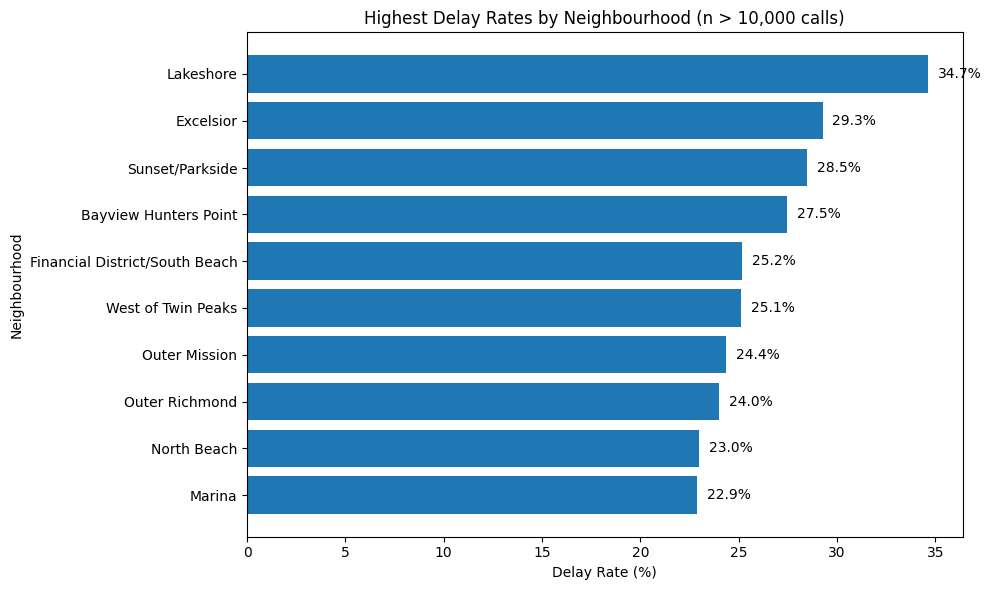

In [28]:
# Prepare data
top_delay_neighborhoods = (
    neighborhood_analysis[neighborhood_analysis['n_calls'] > 10000]
    .sort_values(by='delay_rate', ascending=False)
    .head(10)
    .sort_values(by='delay_rate')  # for horizontal bar chart
)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_delay_neighborhoods.index,
    top_delay_neighborhoods['delay_rate'] * 100
)

plt.title("Highest Delay Rates by Neighbourhood (n > 10,000 calls)")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Neighbourhood")

# Add values at end of bars
for i, value in enumerate(top_delay_neighborhoods['delay_rate'] * 100):
    plt.text(value + 0.5, i, f"{value:.1f}%", va='center')

plt.tight_layout()
plt.show()

Same logic for battalion (quick check)

In [29]:
df_clean.groupby('battalion').size().sort_values(ascending=False)

battalion
B02     173995
B03     152668
B04      93519
B01      83613
B10      66959
B08      66216
B06      57964
B05      57657
B09      56766
B07      45578
B99         29
XXX          5
B13          4
AMB          3
B100         1
dtype: int64

# Controlled Fairness Analysis (CRITICAL)



Now we answer:

“Are these delays still high after controlling for call type & priority?”

Compare within similar conditions

In [30]:
fairness_neighborhood = (
    df_clean
    .groupby(['neighborhoods_analysis_boundaries', 'call_type_group', 'priority'])['response_time']
    .mean()
    .reset_index()
)

fairness_neighborhood.head()

,neighborhoods_analysis_boundaries,call_type_group,priority,response_time
0,Bayview Hunters Point,Alarm,1,1517.676923
1,Bayview Hunters Point,Alarm,2,718.275472
2,Bayview Hunters Point,Alarm,3,520.853736
3,Bayview Hunters Point,Fire,3,632.417226
4,Bayview Hunters Point,Non Life-threatening,1,1904.314504


Compare deviations from expected

In [31]:
# Compute average response time per (call_type_group, priority)
baseline = (
    df_clean
    .groupby(['call_type_group', 'priority'])['response_time']
    .mean()
    .reset_index()
    .rename(columns={'response_time': 'baseline_response_time'})
)

# Merge baseline
df_fair = df_clean.merge(
    baseline,
    on=['call_type_group', 'priority'],
    how='left'
)

# Compute deviation
df_fair['response_time_diff'] = df_fair['response_time'] - df_fair['baseline_response_time']

Aggregate by neighborhood

In [32]:
fairness_result = (
    df_fair
    .groupby('neighborhoods_analysis_boundaries')
    .agg(
        avg_delay=('response_time_diff', 'mean'),
        n_calls=('response_time_diff', 'size')
    )
    .sort_values(by='avg_delay', ascending=False)
)

fairness_result.head(10)

,avg_delay,n_calls
neighborhoods_analysis_boundaries,,
Lincoln Park,241.553257,685
Visitacion Valley,147.867345,8893
McLaren Park,136.214744,468
Presidio,120.464083,5345
Lakeshore,113.447213,13664
Sunset/Parkside,93.287538,31589
Excelsior,71.640304,15686
Seacliff,60.269316,1342
Treasure Island,56.745557,4434


Filter fairness results for meaningful sample size

In [33]:
fairness_result_filtered = (
    fairness_result[fairness_result['n_calls'] > 10000]
    .sort_values(by='avg_delay', ascending=False)
)

fairness_result_filtered.head(10)

,avg_delay,n_calls
neighborhoods_analysis_boundaries,,
Lakeshore,113.447213,13664
Sunset/Parkside,93.287538,31589
Excelsior,71.640304,15686
Financial District/South Beach,53.289949,52692
Bayview Hunters Point,47.998082,43617
North Beach,35.960556,13754
Outer Mission,35.933813,12722
West of Twin Peaks,22.245324,18559
Outer Richmond,21.133321,20726


Also check the bottom (best performing):

In [34]:
fairness_result_filtered.tail(10)

,avg_delay,n_calls
neighborhoods_analysis_boundaries,,
Bernal Heights,-11.634594,16041
Chinatown,-28.676316,15641
Pacific Heights,-32.176666,15554
Mission,-36.513476,81958
Tenderloin,-37.877123,125328
Western Addition,-42.722096,31556
Hayes Valley,-49.765356,22944
Castro/Upper Market,-59.427633,18607
Haight Ashbury,-60.206838,10939


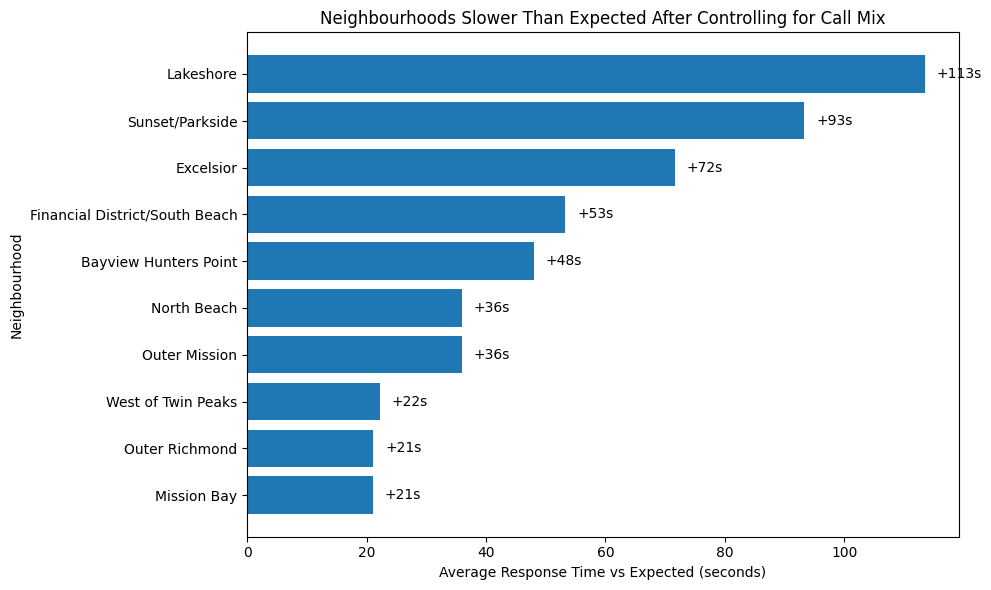

In [35]:
# Prepare data
top_adjusted_delay = (
    fairness_result_filtered
    .sort_values(by='avg_delay', ascending=False)
    .head(10)
    .sort_values(by='avg_delay')
)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_adjusted_delay.index,
    top_adjusted_delay['avg_delay']
)

plt.title("Neighbourhoods Slower Than Expected After Controlling for Call Mix")
plt.xlabel("Average Response Time vs Expected (seconds)")
plt.ylabel("Neighbourhood")

# Add values at end of bars
for i, value in enumerate(top_adjusted_delay['avg_delay']):
    plt.text(value + 2, i, f"+{value:.0f}s", va='center')

plt.tight_layout()
plt.show()

# Additional Operational EDA for Report Revision

## Prep

In [36]:
# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Helper: detect the dataframe you are using
# Adjust this manually if your cleaned dataframe has a different name.
for name in ["df_clean", "df_valid", "df_first_unit", "df_model", "df"]:
    if name in globals():
        print(f"Found dataframe: {name}", globals()[name].shape)

Found dataframe: df_clean (854977, 39)
Found dataframe: df (1095429, 37)


In [37]:
# Use cleaned dataframe for additional operational EDA
eda_df = df_clean.copy()

print(eda_df.shape)
eda_df.head()

(854977, 39)


,call_number,unit_id,incident_number,call_type,call_date,watch_date,received_dttm,entry_dttm,dispatch_dttm,response_dttm,on_scene_dttm,transport_dttm,hospital_dttm,call_final_disposition,available_dttm,address,city,zipcode_of_incident,battalion,station_area,box,original_priority,priority,final_priority,als_unit,call_type_group,number_of_alarms,unit_type,unit_sequence_in_call_dispatch,fire_prevention_district,supervisor_district,neighborhoods_analysis_boundaries,rowid,case_location,data_as_of,data_loaded_at,response_time,response_time_threshold,is_delayed
0,230010392,T03,23000066,Gas Leak (Natural and LP Gases),2023-01-01T00:00:00.000,2022-12-31T00:00:00.000,2023-01-01 01:56:38,2023-01-01T01:58:36.000,2023-01-01 01:59:03,2023-01-01 02:02:27,2023-01-01 02:02:27,NaN,NaN,Fire,2023-01-01T02:11:34.000,GEARY ST/JONES ST,San Francisco,94102.0,B01,3.0,1462.0,3,3,3,True,Alarm,1,TRUCK,1.0,1.0,6.0,Tenderloin,230010392-T03,POINT (-122.41316 37.786728),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000,349.0,513.0,False
1,230010428,52,23000073,Medical Incident,2023-01-01T00:00:00.000,2022-12-31T00:00:00.000,2023-01-01 02:10:43,2023-01-01T02:12:06.000,2023-01-01 02:13:10,2023-01-01 02:13:50,2023-01-01 02:25:45,2023-01-01T02:53:18.000,2023-01-01T03:11:44.000,Code 2 Transport,2023-01-01T03:51:20.000,03RD ST/DONNER AVE,San Francisco,94124.0,B10,17.0,6537.0,3,3,3,True,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,230010428-52,POINT (-122.39453 37.724693),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000,902.0,644.0,True
2,230011485,B05,23000257,Alarms,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01 11:33:00,2023-01-01T11:34:23.000,2023-01-01 11:34:29,2023-01-01 11:35:00,2023-01-01 11:37:50,NaN,NaN,Fire,2023-01-01T12:01:28.000,GOLDEN GATE AVE/MASONIC AVE,San Francisco,94118.0,B05,21.0,4462.0,3,3,3,False,Alarm,1,CHIEF,3.0,5.0,1.0,Lone Mountain/USF,230011485-B05,POINT (-122.446846 37.777668),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000,290.0,513.0,False
6,230012942,62,23000475,Medical Incident,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01 20:09:14,2023-01-01T20:11:24.000,2023-01-01 20:11:41,2023-01-01 20:12:41,2023-01-01 20:16:29,2023-01-01T20:41:29.000,2023-01-01T20:49:18.000,Code 2 Transport,2023-01-01T21:30:57.000,17TH ST/MISSION ST,San Francisco,94110.0,B02,7.0,5236.0,3,3,3,True,Potentially Life-Threatening,1,MEDIC,1.0,2.0,9.0,Mission,230012942-62,POINT (-122.41951 37.763428),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000,435.0,644.0,False
7,230012316,55,23000370,Medical Incident,2023-01-01T00:00:00.000,2023-01-01T00:00:00.000,2023-01-01 16:17:13,2023-01-01T16:19:55.000,2023-01-01 16:20:23,2023-01-01 16:20:32,2023-01-01 16:28:55,2023-01-01T16:54:22.000,2023-01-01T17:23:46.000,Code 2 Transport,2023-01-01T18:24:29.000,NEW MONTGOMERY ST/MARKET ST/MONTGOMERY ST,San Francisco,94105.0,B03,13.0,2109.0,3,3,3,True,Potentially Life-Threatening,1,MEDIC,2.0,1.0,6.0,Financial District/South Beach,230012316-55,POINT (-122.40207 37.788723),2024-02-05T03:27:52.000,2024-02-05T10:56:25.000,702.0,644.0,True


In [38]:
eda_df.columns.tolist()

['call_number',
 'unit_id',
 'incident_number',
 'call_type',
 'call_date',
 'watch_date',
 'received_dttm',
 'entry_dttm',
 'dispatch_dttm',
 'response_dttm',
 'on_scene_dttm',
 'transport_dttm',
 'hospital_dttm',
 'call_final_disposition',
 'available_dttm',
 'address',
 'city',
 'zipcode_of_incident',
 'battalion',
 'station_area',
 'box',
 'original_priority',
 'priority',
 'final_priority',
 'als_unit',
 'call_type_group',
 'number_of_alarms',
 'unit_type',
 'unit_sequence_in_call_dispatch',
 'fire_prevention_district',
 'supervisor_district',
 'neighborhoods_analysis_boundaries',
 'rowid',
 'case_location',
 'data_as_of',
 'data_loaded_at',
 'response_time',
 'response_time_threshold',
 'is_delayed']

In [39]:
# =========================================================
# Standard preparation for additional operational EDA
# =========================================================

# Ensure datetime format
eda_df["received_dttm"] = pd.to_datetime(
    eda_df["received_dttm"],
    errors="coerce"
)

# Detect response time column
possible_response_cols = [
    "response_time_seconds",
    "response_time_sec",
    "response_time",
    "response_seconds"
]

response_col = None

for col in possible_response_cols:
    if col in eda_df.columns:
        response_col = col
        break

print("Detected response time column:", response_col)

# Create response time if missing
if response_col is None:
    eda_df["response_time_seconds"] = (
        pd.to_datetime(eda_df["on_scene_dttm"], errors="coerce")
        - pd.to_datetime(eda_df["received_dttm"], errors="coerce")
    ).dt.total_seconds()

    response_col = "response_time_seconds"

# Final validation
eda_df = eda_df[
    eda_df["received_dttm"].notna()
    & eda_df[response_col].notna()
    & (eda_df[response_col] >= 0)
].copy()

# Create minutes version
eda_df["response_time_minutes"] = eda_df[response_col] / 60

# Time features
eda_df["hour"] = eda_df["received_dttm"].dt.hour
eda_df["day_of_week"] = eda_df["received_dttm"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

print("Final EDA dataframe shape:", eda_df.shape)

eda_df[
    [
        "received_dttm",
        response_col,
        "response_time_minutes",
        "hour",
        "day_of_week"
    ]
].head()

Detected response time column: response_time
Final EDA dataframe shape: (854977, 42)


,received_dttm,response_time,response_time_minutes,hour,day_of_week
0,2023-01-01 01:56:38,349.0,5.816667,1,Sunday
1,2023-01-01 02:10:43,902.0,15.033333,2,Sunday
2,2023-01-01 11:33:00,290.0,4.833333,11,Sunday
6,2023-01-01 20:09:14,435.0,7.250000,20,Sunday
7,2023-01-01 16:17:13,702.0,11.700000,16,Sunday


## 1 - Temporal Operational Patterns

### 1.1 Response time by hour of day

Goal:

identify operational congestion periods,
support business questions,
justify temporal features for modelling.

Outputs:

median response time by hour,
optionally 80th percentile by hour.

Recommended plot:

line chart.

In [40]:
# =========================================================
# 1.1 Response time by hour of day
# =========================================================

hour_summary = (
    eda_df
    .groupby("hour")["response_time_minutes"]
    .agg(
        count="count",
        median="median",
        p80=lambda x: x.quantile(0.80),
        mean="mean"
    )
    .reset_index()
)

hour_summary

,hour,count,median,p80,mean
0,0,27036,8.183333,13.800000,14.916492
1,1,24333,8.266667,13.616667,11.106962
2,2,22386,8.350000,13.683333,10.782039
3,3,19104,8.616667,14.350000,11.518143
4,4,17614,8.583333,14.316667,11.247210
5,5,18190,8.733333,15.400000,12.124109
6,6,21394,8.500000,15.023333,11.862890
7,7,28234,8.133333,14.766667,11.281045
8,8,35382,8.166667,15.413333,11.587770
9,9,41660,8.300000,15.483333,11.813051


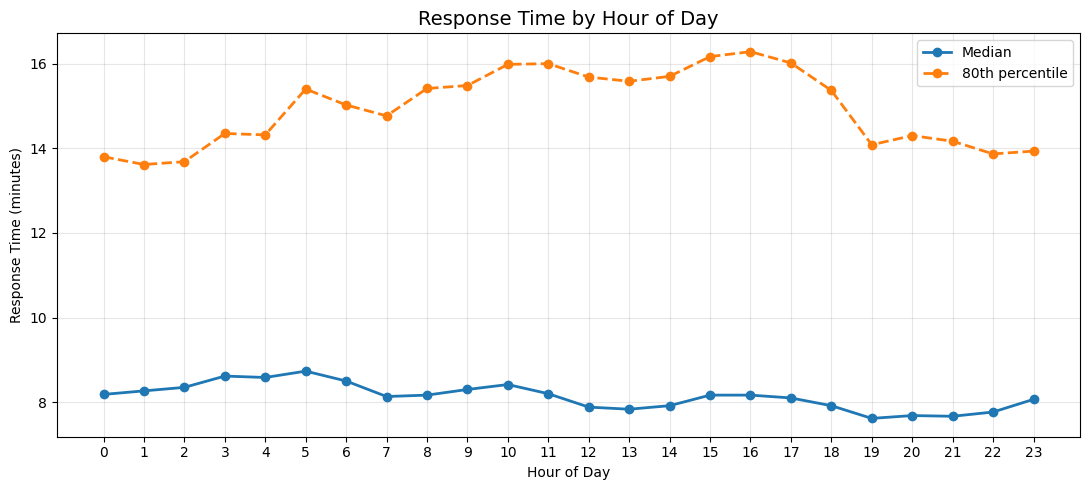

In [41]:
plt.figure(figsize=(11, 5))

plt.plot(
    hour_summary["hour"],
    hour_summary["median"],
    marker="o",
    linewidth=2,
    label="Median"
)

plt.plot(
    hour_summary["hour"],
    hour_summary["p80"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="80th percentile"
)

plt.title("Response Time by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Response Time (minutes)")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figure_A4_response_time_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
hour_summary.sort_values("median", ascending=False).head(5)

,hour,count,median,p80,mean
5,5,18190,8.733333,15.400000,12.124109
3,3,19104,8.616667,14.350000,11.518143
4,4,17614,8.583333,14.316667,11.247210
6,6,21394,8.500000,15.023333,11.862890
10,10,45061,8.416667,15.983333,11.937887


In [43]:
hour_summary.sort_values("median", ascending=True).head(5)

,hour,count,median,p80,mean
19,19,42342,7.616667,14.083333,10.550581
21,21,36824,7.666667,14.166667,10.547912
20,20,39960,7.683333,14.300000,10.740737
22,22,33049,7.766667,13.866667,10.473628
13,13,48281,7.833333,15.583333,11.380514


And interestingly, the pattern is subtler than expected, which is actually good from an analytical standpoint because you can avoid overclaiming.

#### Main interpretation

The strongest pattern is not in the median itself, but in the:

upper tail (80th percentile),
variability throughout the day.

Key observations:

Median response times remain relatively stable throughout the day (~7.6–8.7 min)
The 80th percentile increases during daytime and afternoon operational peaks
The slowest periods occur approximately between 10:00–17:00
Evening hours (19:00–22:00) exhibit the fastest overall response profiles
This suggests that congestion and operational load primarily affect longer-delay incidents rather than typical calls

This is actually a very good business insight.

#### Important observation

Your plot supports a nuanced conclusion:

“typical calls remain stable”
BUT
“risk of longer delays increases during busy daytime periods.”

That sounds much more professional than:

“everything is slower during the day.”

#### This is report-ready wording

You can later insert something very close to this:

Response times exhibit moderate temporal variation throughout the day. Median response times remain relatively stable, while the upper tail of the distribution increases during daytime and afternoon operational periods. In particular, the 80th percentile response time peaks between approximately 10:00 and 17:00, suggesting that operational congestion primarily affects longer-delay incidents rather than typical calls.

### 1.2 Response time by day of week



Goal:

evaluate weekly operational variation.

Outputs:

median response time by weekday.

Recommended plot:

ordered bar chart.

In [44]:
# =========================================================
# 1.2 Response time by day of week
# =========================================================

weekday_summary = (
    eda_df
    .groupby("day_of_week")["response_time_minutes"]
    .agg(
        count="count",
        median="median",
        p80=lambda x: x.quantile(0.80),
        mean="mean"
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_summary

,day_of_week,count,median,p80,mean
0,Monday,124345,8.050000,15.000000,11.460494
1,Tuesday,121535,8.133333,15.333333,11.724081
2,Wednesday,122765,8.150000,15.416667,11.820704
3,Thursday,122018,8.150000,15.316667,11.734275
4,Friday,125173,8.166667,15.433333,12.030903
5,Saturday,120752,8.033333,14.633333,11.126943
6,Sunday,118389,7.950000,14.383333,10.862508


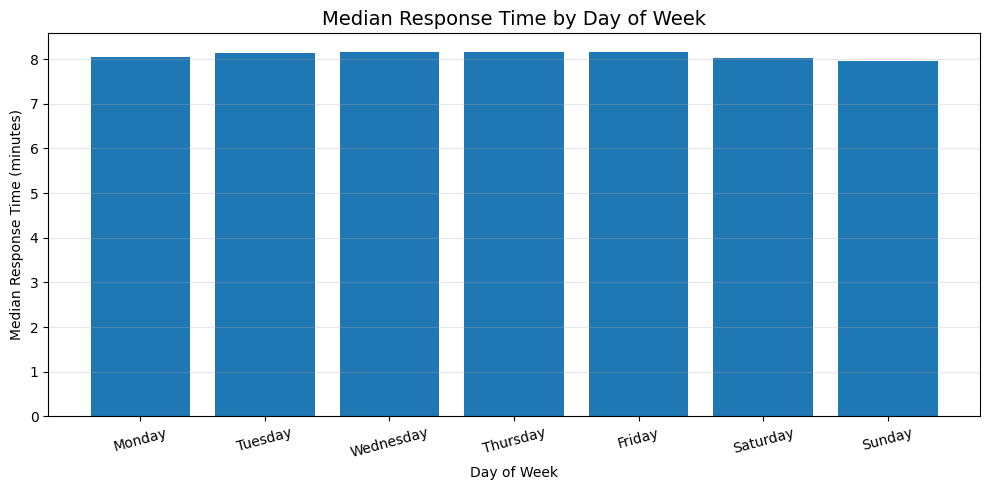

In [45]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_summary["day_of_week"],
    weekday_summary["median"]
)

plt.title("Median Response Time by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Median Response Time (minutes)")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_A5_response_time_by_weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
weekday_summary.sort_values("median", ascending=False)

,day_of_week,count,median,p80,mean
4,Friday,125173,8.166667,15.433333,12.030903
3,Thursday,122018,8.150000,15.316667,11.734275
2,Wednesday,122765,8.150000,15.416667,11.820704
1,Tuesday,121535,8.133333,15.333333,11.724081
0,Monday,124345,8.050000,15.000000,11.460494
5,Saturday,120752,8.033333,14.633333,11.126943
6,Sunday,118389,7.950000,14.383333,10.862508


And again, the result is nuanced and realistic, which strengthens the report credibility.

#### Main interpretation

The weekly variation exists, but it is relatively modest:

weekdays are consistently slightly slower,
Friday is the slowest day,
Sunday is the fastest.

Most importantly:

differences are much smaller than the neighbourhood disparities you previously found.

That’s a very strong comparative business statement.

#### Strong report-ready conclusion

You can later write something close to:

Response times exhibit limited variation across days of the week. Weekdays, particularly Thursday and Friday, show slightly higher response times, while weekends exhibit somewhat faster response profiles. However, these temporal differences are modest compared to the geographic disparities observed across neighbourhoods and battalions.

That’s exactly the type of concise operational interpretation instructors like.

#### Important insight

Your results now support a hierarchy of operational drivers:

- Stronger drivers : 
geography,
battalion,
neighbourhood,
call type.
- Weaker drivers :
day of week,
hour of day (for median cases).

This is excellent because it helps justify:

feature importance expectations,
modelling strategy,
fairness framing.


## 2 - Call-Type Operational Analysis

### 2.1 Response time by call type group


Goal:

support:
delay definition,
fairness interpretation,
modelling design.

Outputs:

median,
80th percentile,
possibly boxplot.

This will become strong evidence for:

“single threshold inappropriate.”

We want to demonstrate clearly:

different incident categories naturally have different operational response profiles.

That strongly supports:

- no global delay threshold,
- context-aware evaluation,
- fairness adjustment.

In [47]:
# =========================================================
# 2.1 Response time by call type group
# =========================================================

call_type_summary = (
    eda_df
    .groupby("call_type_group")
    .agg(
        calls=("response_time_minutes", "count"),
        median_response=("response_time_minutes", "median"),
        p80_response=("response_time_minutes", lambda x: x.quantile(0.80)),
        mean_response=("response_time_minutes", "mean")
    )
    .reset_index()
    .sort_values("median_response")
)

call_type_summary

,call_type_group,calls,median_response,p80_response,mean_response
0,Alarm,187649,6.750000,9.000000,8.009897
1,Fire,35858,7.066667,11.466667,13.363093
3,Potentially Life-Threatening,425567,7.700000,12.166667,9.765014
2,Non Life-threatening,188393,15.116667,23.700000,17.689092


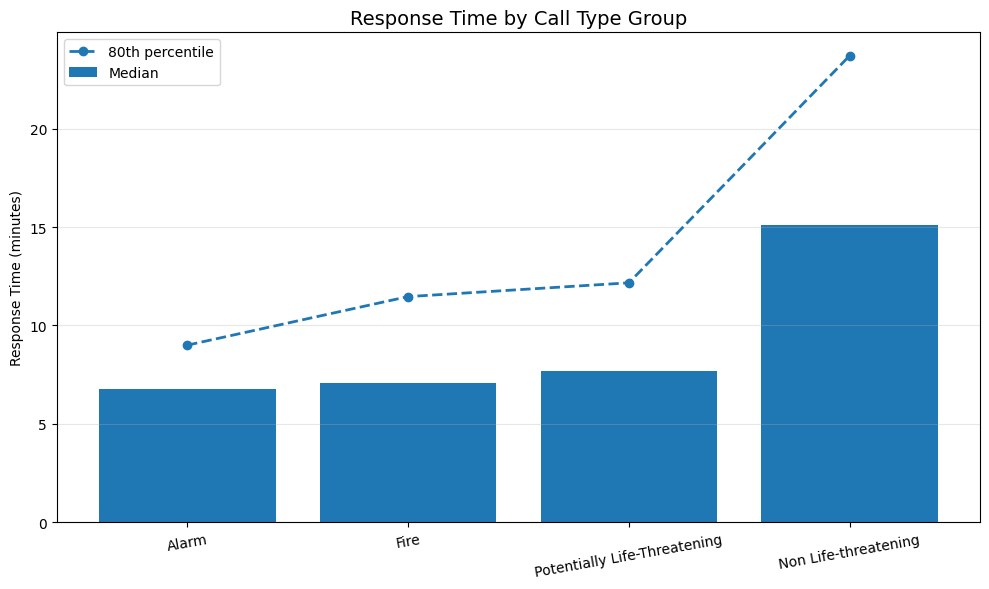

In [48]:
plt.figure(figsize=(10, 6))

x = np.arange(len(call_type_summary))

plt.bar(
    x,
    call_type_summary["median_response"],
    label="Median"
)

plt.plot(
    x,
    call_type_summary["p80_response"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="80th percentile"
)

plt.xticks(
    x,
    call_type_summary["call_type_group"],
    rotation=10
)

plt.title("Response Time by Call Type Group", fontsize=14)
plt.ylabel("Response Time (minutes)")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_A6_response_time_by_call_type_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
call_type_summary.sort_values(
    "median_response",
    ascending=False
)

,call_type_group,calls,median_response,p80_response,mean_response
2,Non Life-threatening,188393,15.116667,23.700000,17.689092
3,Potentially Life-Threatening,425567,7.700000,12.166667,9.765014
1,Fire,35858,7.066667,11.466667,13.363093
0,Alarm,187649,6.750000,9.000000,8.009897


In [50]:
call_type_summary["p80_minus_median"] = (
    call_type_summary["p80_response"]
    - call_type_summary["median_response"]
)

call_type_summary[
    [
        "call_type_group",
        "median_response",
        "p80_response",
        "p80_minus_median"
    ]
].sort_values(
    "p80_minus_median",
    ascending=False
)

,call_type_group,median_response,p80_response,p80_minus_median
2,Non Life-threatening,15.116667,23.700000,8.583333
3,Potentially Life-Threatening,7.700000,12.166667,4.466667
1,Fire,7.066667,11.466667,4.400000
0,Alarm,6.750000,9.000000,2.250000


Excellent. This is probably the strongest new analysis so far.

And this directly addresses both:

* instructor feedback,
* client fairness concerns,
* modelling rationale.

#### This result is VERY important

You now have strong quantitative evidence that:

> a single global delay threshold would be operationally misleading.

The differences are huge.

---

### Main operational insight

#### Non Life-threatening calls

* median ≈ 15.1 min
* 80th percentile ≈ 23.7 min

#### Alarm calls

* median ≈ 6.8 min
* 80th percentile ≈ 9.0 min

That is more than a 2x difference in operational response profiles.

This is excellent evidence for your:

* percentile-based delay definition,
* fairness adjustment methodology,
* subgroup-aware modelling evaluation.

---

### Strongest insight

The variability itself differs substantially across groups:

| Group                        | p80 - median |
| ---------------------------- | ------------ |
| Non Life-threatening         | 8.58 min     |
| Potentially Life-Threatening | 4.47 min     |
| Fire                         | 4.40 min     |
| Alarm                        | 2.25 min     |

This means:

* some incident types are operationally much less predictable,
* tail-risk differs by call category.

That is a sophisticated operational finding.

---

### Extremely strong report-ready interpretation

You can later include something close to:

> Response times vary substantially across call type groups. Non Life-threatening incidents exhibit markedly slower and more variable response profiles than emergency-oriented categories such as Alarm, Fire, and Potentially Life-Threatening incidents. In particular, the 80th percentile response time for Non Life-threatening calls exceeds 23 minutes, compared with approximately 9 minutes for Alarm calls. These differences strongly support the use of context-aware delay definitions rather than a single global threshold across all incident types.

That is high-quality business/technical writing.

---

### Important modelling implication

This analysis now strongly justifies:

* using `call_type_group`,
* subgroup evaluation,
* fairness adjustment,
* potential interaction effects,
* heteroskedasticity concerns,
* possibly separate operational performance regimes.

This also strengthens your:

* “Expected risks” section,
* “Expected performance” section.



## 3 - Battalion Performance Analysis

### 3.1 Battalion-level response patterns



This is probably the most important missing analysis.

Goal:

answer explicit client request about operational districts,
identify systematic underperformance.

Outputs:

battalion median response time,
battalion delay rate,
optionally adjusted battalion comparison.

Recommended:

sorted horizontal bar chart.

In [51]:
# =========================================================
# 3.1 Battalion-level response patterns
# =========================================================

battalion_summary = (
    eda_df
    .groupby("battalion")
    .agg(
        calls=("response_time_minutes", "count"),
        median_response=("response_time_minutes", "median"),
        p80_response=("response_time_minutes", lambda x: x.quantile(0.80)),
        mean_response=("response_time_minutes", "mean"),
        delay_rate=("is_delayed", "mean")
    )
    .reset_index()
)

# Convert delay rate to percentage
battalion_summary["delay_rate_pct"] = (
    battalion_summary["delay_rate"] * 100
)

# Sort by delay rate
battalion_summary = battalion_summary.sort_values(
    "delay_rate_pct",
    ascending=False
)

battalion_summary

,battalion,calls,median_response,p80_response,mean_response,delay_rate,delay_rate_pct
0,AMB,3,0.000000,15.510000,8.616667,0.333333,33.333333
8,B08,66216,9.050000,16.400000,12.516564,0.285037,28.503685
9,B09,56766,9.566667,16.366667,12.383636,0.284378,28.437797
13,B99,29,1.466667,13.750000,146.549425,0.275862,27.586207
10,B10,66959,8.966667,15.766667,11.875214,0.254589,25.458863
7,B07,45578,8.250000,15.200000,11.713607,0.245162,24.516214
3,B03,152668,8.383333,16.466667,12.684612,0.216620,21.662038
1,B01,83613,7.666667,14.466667,11.050892,0.194455,19.445541
6,B06,57964,7.883333,14.283333,11.540698,0.183114,18.311366
4,B04,93519,7.350000,13.833333,10.509521,0.170350,17.035041


In [52]:
battalion_summary[
    [
        "battalion",
        "calls",
        "median_response",
        "p80_response",
        "delay_rate_pct"
    ]
]

,battalion,calls,median_response,p80_response,delay_rate_pct
0,AMB,3,0.000000,15.510000,33.333333
8,B08,66216,9.050000,16.400000,28.503685
9,B09,56766,9.566667,16.366667,28.437797
13,B99,29,1.466667,13.750000,27.586207
10,B10,66959,8.966667,15.766667,25.458863
7,B07,45578,8.250000,15.200000,24.516214
3,B03,152668,8.383333,16.466667,21.662038
1,B01,83613,7.666667,14.466667,19.445541
6,B06,57964,7.883333,14.283333,18.311366
4,B04,93519,7.350000,13.833333,17.035041


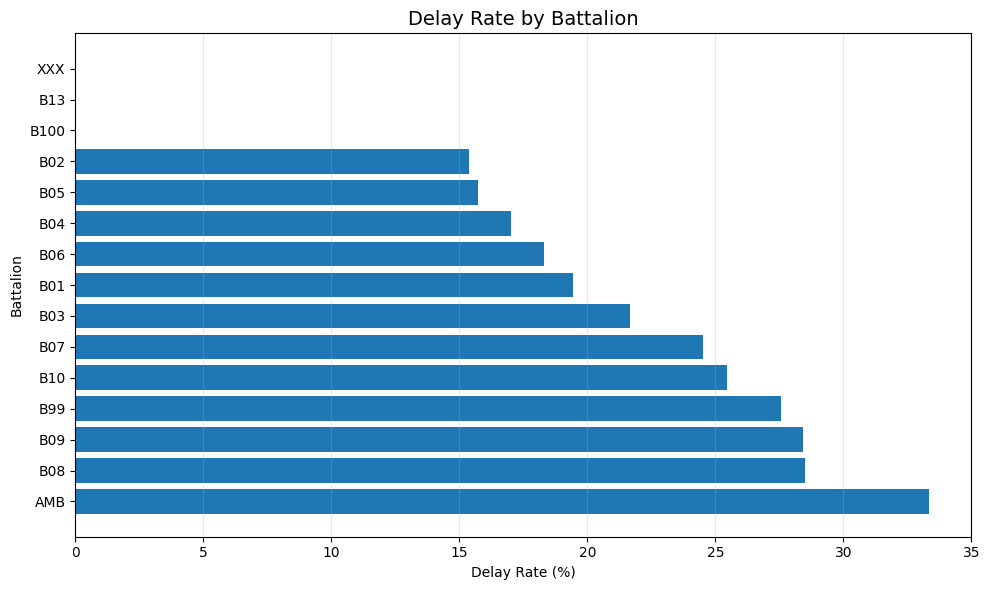

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    battalion_summary["battalion"],
    battalion_summary["delay_rate_pct"]
)

plt.title("Delay Rate by Battalion", fontsize=14)
plt.xlabel("Delay Rate (%)")
plt.ylabel("Battalion")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_A7_battalion_delay_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
battalion_summary.sort_values(
    "delay_rate_pct",
    ascending=False
).head(5)

,battalion,calls,median_response,p80_response,mean_response,delay_rate,delay_rate_pct
0,AMB,3,0.000000,15.510000,8.616667,0.333333,33.333333
8,B08,66216,9.050000,16.400000,12.516564,0.285037,28.503685
9,B09,56766,9.566667,16.366667,12.383636,0.284378,28.437797
13,B99,29,1.466667,13.750000,146.549425,0.275862,27.586207
10,B10,66959,8.966667,15.766667,11.875214,0.254589,25.458863


In [55]:
battalion_summary.sort_values(
    "delay_rate_pct",
    ascending=True
).head(5)

,battalion,calls,median_response,p80_response,mean_response,delay_rate,delay_rate_pct
14,XXX,5,0.000000,0.066667,0.026667,0.000000,0.000000
11,B100,1,0.000000,0.000000,0.000000,0.000000,0.000000
12,B13,4,0.000000,0.000000,0.000000,0.000000,0.000000
2,B02,173995,7.616667,14.183333,10.847649,0.153642,15.364235
5,B05,57657,7.366667,13.400000,10.469109,0.157344,15.734429


Excellent — this is a very valuable result.

But before using it in the report, we need one important cleanup step.

Right now:

AMB,
B99,
B100,
B13,
XXX

are clearly anomalous/sparse battalion codes.

Those tiny sample sizes are distorting the chart and are not operationally meaningful.

This is actually a good example of:

“documented data-quality handling”
which the client explicitly requested.

So now we should filter battalions to:

reliable operational battalions only,
sufficient call volume.

This will make the analysis much more professional.

#### Step 1 — Filter battalions with sufficient observations

In [56]:
# Keep only battalions with meaningful operational volume

MIN_CALLS = 10000

battalion_filtered = battalion_summary[
    battalion_summary["calls"] >= MIN_CALLS
].copy()

battalion_filtered = battalion_filtered.sort_values(
    "delay_rate_pct",
    ascending=False
)

battalion_filtered

,battalion,calls,median_response,p80_response,mean_response,delay_rate,delay_rate_pct
8,B08,66216,9.050000,16.400000,12.516564,0.285037,28.503685
9,B09,56766,9.566667,16.366667,12.383636,0.284378,28.437797
10,B10,66959,8.966667,15.766667,11.875214,0.254589,25.458863
7,B07,45578,8.250000,15.200000,11.713607,0.245162,24.516214
3,B03,152668,8.383333,16.466667,12.684612,0.216620,21.662038
1,B01,83613,7.666667,14.466667,11.050892,0.194455,19.445541
6,B06,57964,7.883333,14.283333,11.540698,0.183114,18.311366
4,B04,93519,7.350000,13.833333,10.509521,0.170350,17.035041
5,B05,57657,7.366667,13.400000,10.469109,0.157344,15.734429
2,B02,173995,7.616667,14.183333,10.847649,0.153642,15.364235


#### Step 2 — Clean visualization

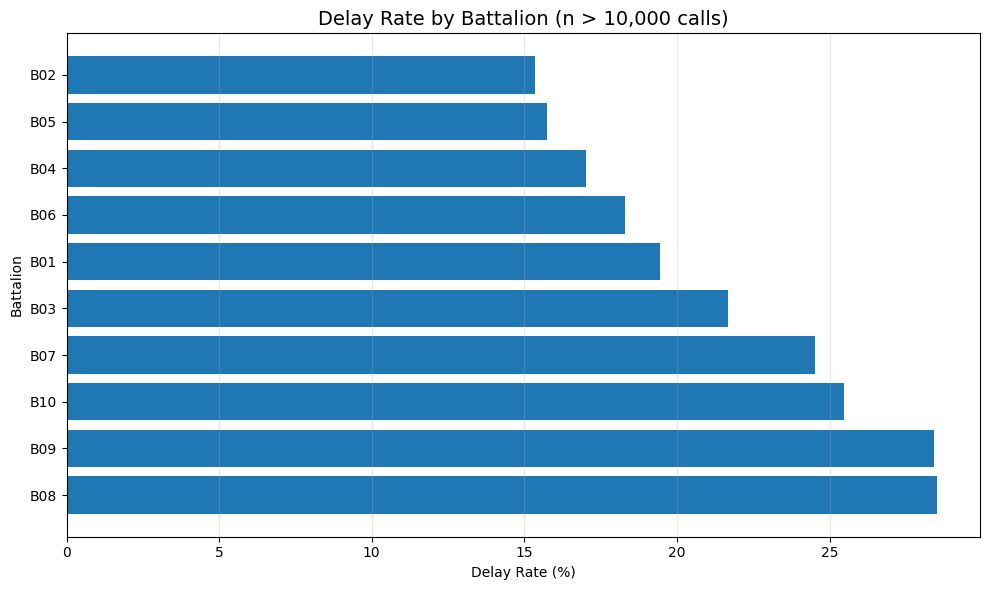

In [57]:
plt.figure(figsize=(10, 6))

plt.barh(
    battalion_filtered["battalion"],
    battalion_filtered["delay_rate_pct"]
)

plt.title(
    f"Delay Rate by Battalion (n > {MIN_CALLS:,} calls)",
    fontsize=14
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Battalion")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_A7_battalion_delay_rates_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Step 3 — Final ranking tables

In [58]:
battalion_filtered[
    [
        "battalion",
        "calls",
        "median_response",
        "p80_response",
        "delay_rate_pct"
    ]
].sort_values(
    "delay_rate_pct",
    ascending=False
)

,battalion,calls,median_response,p80_response,delay_rate_pct
8,B08,66216,9.050000,16.400000,28.503685
9,B09,56766,9.566667,16.366667,28.437797
10,B10,66959,8.966667,15.766667,25.458863
7,B07,45578,8.250000,15.200000,24.516214
3,B03,152668,8.383333,16.466667,21.662038
1,B01,83613,7.666667,14.466667,19.445541
6,B06,57964,7.883333,14.283333,18.311366
4,B04,93519,7.350000,13.833333,17.035041
5,B05,57657,7.366667,13.400000,15.734429
2,B02,173995,7.616667,14.183333,15.364235


In [59]:
battalion_filtered[
    [
        "battalion",
        "calls",
        "median_response",
        "p80_response",
        "delay_rate_pct"
    ]
].sort_values(
    "delay_rate_pct",
    ascending=True
)

,battalion,calls,median_response,p80_response,delay_rate_pct
2,B02,173995,7.616667,14.183333,15.364235
5,B05,57657,7.366667,13.400000,15.734429
4,B04,93519,7.350000,13.833333,17.035041
6,B06,57964,7.883333,14.283333,18.311366
1,B01,83613,7.666667,14.466667,19.445541
3,B03,152668,8.383333,16.466667,21.662038
7,B07,45578,8.250000,15.200000,24.516214
10,B10,66959,8.966667,15.766667,25.458863
9,B09,56766,9.566667,16.366667,28.437797
8,B08,66216,9.050000,16.400000,28.503685


Perfect — this is now a strong, report-quality operational analysis.

This directly resolves the instructor’s:

> “how do response times vary across battalions?”

comment.

And the filtering step made the analysis much more defensible.

### Main operational findings

You now have clear evidence of substantial battalion-level disparities.

#### Highest delay-rate battalions

| Battalion | Delay Rate |
| --------- | ---------- |
| B08       | 28.5%      |
| B09       | 28.4%      |
| B10       | 25.5%      |
| B07       | 24.5%      |

#### Best-performing battalions

| Battalion | Delay Rate |
| --------- | ---------- |
| B02       | 15.4%      |
| B05       | 15.7%      |
| B04       | 17.0%      |

That’s a very large operational spread:

* ~15% → ~28.5%
* almost a 2x difference in delay rates.

This is a meaningful business result.

---

### Strong report-ready interpretation

You can later include something close to:

> Substantial variation exists across battalions. After restricting the analysis to battalions with sufficient operational volume, delay rates range from approximately 15% to 29%. Battalions B08, B09, and B10 exhibit the highest delay rates, while B02 and B05 consistently perform better. These findings suggest that operational disparities are not uniformly distributed across the emergency response network.

That is strong client-facing language.

---

### Important analytical insight

Notice something very interesting:

#### B03

* enormous call volume (~153k)
* middling/high delay rate (~21.7%)

#### B08/B09

* lower volume
* much worse performance

This supports an important fairness/business conclusion:

> high operational demand alone does not fully explain poorer performance.

That aligns nicely with your earlier neighbourhood fairness findings.

---

#### Another strong insight

The battalion differences are MUCH larger than:

* day-of-week differences,
* hour-of-day median differences.

This helps establish:

* geography/operations are dominant drivers,
* temporal effects are secondary.

That’s excellent modelling context.

---

#### At this point, the EDA additions are successful

You now have strong evidence covering:

| Requirement                   | Status |
| ----------------------------- | ------ |
| Time of day                   | ✅      |
| Day of week                   | ✅      |
| Call type                     | ✅      |
| Delay-threshold justification | ✅      |
| Battalion disparities         | ✅      |
| Geographic fairness           | ✅      |

This is enough to substantially improve the revised report.

---

#### Optional next step (recommended but lightweight)

Before moving to report rewriting, I would do ONE final compact analysis:

#### 4 — Optional Zip Code Analysis

## 4 - Optional Zip Code Analysis

In [60]:
# =========================================================
# 4 - Optional Zip Code Analysis
# =========================================================

zipcode_summary = (
    eda_df
    .groupby("zipcode_of_incident")
    .agg(
        calls=("response_time_minutes", "count"),
        median_response=("response_time_minutes", "median"),
        delay_rate=("is_delayed", "mean")
    )
    .reset_index()
)

zipcode_summary["delay_rate_pct"] = (
    zipcode_summary["delay_rate"] * 100
)

# Keep only reliable zip codes
zipcode_summary = zipcode_summary[
    zipcode_summary["calls"] >= 5000
].copy()

zipcode_summary = zipcode_summary.sort_values(
    "delay_rate_pct",
    ascending=False
)

zipcode_summary.head(10)

,zipcode_of_incident,calls,median_response,delay_rate,delay_rate_pct
20,94129.0,5083,10.733333,0.412158,41.215817
23,94132.0,21115,9.783333,0.340374,34.037414
25,94134.0,20020,10.216667,0.324925,32.492507
12,94116.0,18396,8.983333,0.282725,28.272451
3,94105.0,22729,8.983333,0.280083,28.008271
18,94124.0,40706,9.358333,0.272392,27.239228
19,94127.0,7836,8.883333,0.260082,26.008167
9,94112.0,36820,9.233333,0.255894,25.589354
15,94121.0,20758,8.300000,0.255564,25.556412
22,94131.0,13310,8.700000,0.253343,25.334335


In [61]:
zipcode_summary.tail(10)

,zipcode_of_incident,calls,median_response,delay_rate,delay_rate_pct
24,94133.0,24312,8.000000,0.210349,21.034880
14,94118.0,23441,7.700000,0.190905,19.090482
5,94108.0,18765,7.516667,0.184812,18.481215
1,94103.0,128442,8.100000,0.177208,17.720839
0,94102.0,108962,7.683333,0.164902,16.490153
10,94114.0,23038,7.716667,0.164771,16.477125
7,94110.0,66146,7.633333,0.162051,16.205062
6,94109.0,88256,7.166667,0.155502,15.550218
13,94117.0,25708,7.166667,0.151782,15.178155
11,94115.0,33575,7.200000,0.150797,15.079672


This zip code analysis successfully completes the remaining operational coverage from the client brief.

### Main findings

You now have clear zip-code-level disparities:

#### Highest delay-rate zip codes

| Zip Code | Delay Rate |
| -------- | ---------- |
| 94129    | 41.2%      |
| 94132    | 34.0%      |
| 94134    | 32.5%      |

#### Lowest delay-rate zip codes

| Zip Code | Delay Rate |
| -------- | ---------- |
| 94115    | 15.1%      |
| 94117    | 15.2%      |
| 94109    | 15.6%      |

That’s a very large spread.

---

### Important analytical nuance

Some of the higher-delay zip codes:

* have relatively moderate call volumes,
* geographically peripheral locations,
* likely longer travel distances.

Meanwhile:

* dense urban zip codes like:

  * 94109,
  * 94110,
  * 94102,
    perform comparatively well.

This strongly reinforces one of your strongest report conclusions:

> higher demand does not necessarily imply poorer performance.

That’s an excellent operational insight.

---

### Strong report-ready wording

You can later include something close to:

> Substantial variation is also observed across zip codes. After filtering for reliable call volumes, delay rates range from approximately 15% to over 40%. Several peripheral zip codes exhibit markedly higher delay rates, while dense central areas often perform comparatively well. This reinforces the conclusion that operational disparities are geographically uneven and not solely driven by call volume.

Very strong client-facing language.

---

## 5 - Report Updates

### IMPORTANT: Stop EDA here

At this point, continuing exploratory work would likely:

* add complexity,
* dilute the report,
* create scope creep.

You already have more than enough evidence to fully address the instructor comments.

---

### What you achieved with this EDA extension

You substantially strengthened:

#### Business completeness

You now explicitly cover:

* time of day,
* day of week,
* call type,
* battalion,
* zip code,
* fairness geography.

#### Modelling rationale

You now have evidence supporting:

* subgroup-aware evaluation,
* relative thresholds,
* operational heterogeneity,
* temporal features,
* geographic features.

#### Fairness framing

You now clearly demonstrate:

* raw disparities,
* operational context,
* geographic variability,
* differing incident profiles.

---


